# Dynamic Gesture Recognition with LSTM
## Розширення існуючої системи ASL для жестів з рухом (Z, J тощо)

### Архітектурна ідея:
- MediaPipe дає нам 21 ключових точки руки (63 координати) **на кожен кадр**
- Для динамічних жестів ми збираємо **послідовність** таких кадрів (sequence)
- LSTM (або GRU) навчається розпізнавати **патерн руху** в цій послідовності
- MLP залишається для статичних букв — гібридна система вирішує, яку модель використати

## Крок 1: Встановлення залежностей

In [92]:
!pip install mediapipe tensorflow scikit-learn numpy pandas matplotlib seaborn opencv-python-headless


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Крок 2: Збір датасету для динамічних жестів

### Логіка:
- Для кожного жесту (Z, J, etc.) записуємо N відеокліпів
- Кожен кліп = SEQUENCE_LENGTH кадрів
- З кожного кадру MediaPipe витягує 63 числа (21 точка × x,y,z)
- Зберігаємо як numpy array: shape `(кількість_семплів, SEQUENCE_LENGTH, 63)`

## Крок 3: Завантаження та перевірка датасету

In [93]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

DATA_DIR = 'dataset_lstm/dynamic_dataset'
SEQUENCE_LENGTH = 40

def load_dynamic_dataset(data_dir):
    X, y, classes = [], [], []
    
    gesture_dirs = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])
    classes = gesture_dirs
    label_map = {g: i for i, g in enumerate(gesture_dirs)}

    for gesture in gesture_dirs:
        gesture_dir = os.path.join(data_dir, gesture)
        files = [f for f in os.listdir(gesture_dir) if f.endswith('.npy')]
        print(f"  [{gesture}]: {len(files)} samples")
        for f in files:
            seq = np.load(os.path.join(gesture_dir, f))
            if seq.shape == (SEQUENCE_LENGTH, 63):
                X.append(seq)
                y.append(label_map[gesture])
            else:
                print(f"Skipping {f}: shape {seq.shape}")
    
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), classes


print("Loading dataset...")
X, y, CLASSES = load_dynamic_dataset(DATA_DIR)
print(f"\nDataset: X={X.shape}, y={y.shape}")
print(f"Classes: {CLASSES}")
print(f"Distribution: {dict(zip(CLASSES, np.bincount(y)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

Loading dataset...
  [J]: 400 samples
  [Z]: 400 samples
  [kolo]: 407 samples

Dataset: X=(1207, 40, 63), y=(1207,)
Classes: ['J', 'Z', 'kolo']
Distribution: {'J': np.int64(400), 'Z': np.int64(400), 'kolo': np.int64(407)}

Train: (965, 40, 63), Test: (242, 40, 63)


## Крок 4: Побудова LSTM/GRU моделі

### Порівнюємо 3 архітектури:
| Модель | Плюси | Мінуси |
|--------|-------|--------|
| LSTM | Добре для довгих залежностей | Повільніше |
| GRU | Швидше, часто краще на малих даних | Менше параметрів |
| CNN+GRU | Локальні патерни + часові залежності | Складніше |

**Рекомендація:** Спочатку пробуй GRU — на малих датасетах (100-500 семплів) вона часто краща за LSTM.

In [94]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, GlobalAveragePooling1D, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

NUM_CLASSES    = len(CLASSES)
INPUT_SHAPE    = (SEQUENCE_LENGTH, 63) 

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)


def build_lstm_model():
    """Класичний стек LSTM."""
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=INPUT_SHAPE),
        BatchNormalization(),
        Dropout(0.3),
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='LSTM_model')
    return model


def build_gru_model():
    """GRU — зазвичай краще на малих датасетах."""
    model = Sequential([
        GRU(128, return_sequences=True, input_shape=INPUT_SHAPE),
        BatchNormalization(),
        Dropout(0.3),
        GRU(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='GRU_model')
    return model


def build_cnn_gru_model():
    """CNN витягує локальні патерни → GRU вчить часові залежності."""
    inputs = Input(shape=INPUT_SHAPE)
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = GRU(64, return_sequences=False)(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)
    return Model(inputs, outputs, name='CNN_GRU_model')


model = build_gru_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\user\.virtualenvs\ml_firman-h99lXOvd\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "GRU_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_31 (GRU)                    │ (None, 40, 128)        │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 40, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 40, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_32 (GRU)                    │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,483 (455.01 KB)

 Trainable params: 116,099 (453.51 KB)

 Non-trainable params: 384 (1.50 KB)

## Крок 5: Тренування моделі

Epoch 1/150
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6747 - loss: 0.7196
Epoch 1: val_accuracy improved from None to 0.90909, saving model to best_dynamic_model.keras

Epoch 1: finished saving model to best_dynamic_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.8124 - loss: 0.4268 - val_accuracy: 0.9091 - val_loss: 0.6542 - learning_rate: 0.0010
Epoch 2/150
29/31 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9217 - loss: 0.2048
Epoch 2: val_accuracy did not improve from 0.90909
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9181 - loss: 0.1996 - val_accuracy: 0.8926 - val_loss: 0.5534 - learning_rate: 0.0010
Epoch 3/150
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9184 - loss: 0.1976
Epoch 3: val_accuracy improved from 0.90909 to 0.92562, saving model to best_dynamic_model.keras

Epoch 3: finished saving model to best_dynamic_model.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9192 - loss: 0.1900 - val_accuracy: 0.9256 - v

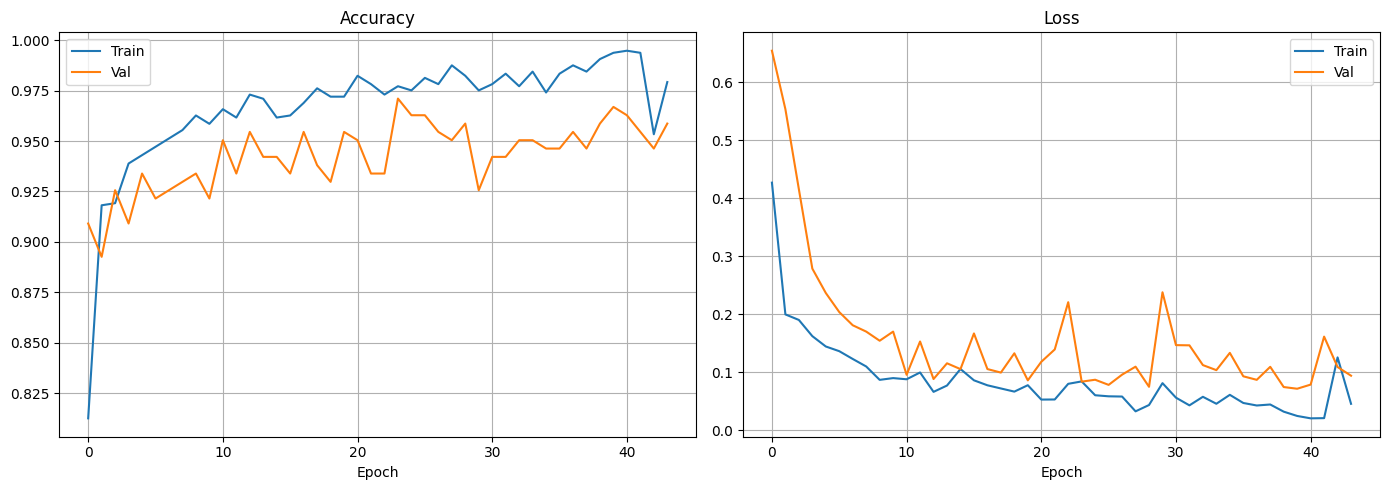


Краща val_accuracy: 0.9711


In [96]:
import matplotlib.pyplot as plt

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_dynamic_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Графіки
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print(f"\nКраща val_accuracy: {max(history.history['val_accuracy']):.4f}")

## Крок 6: Оцінка та Confusion Matrix

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Test Accuracy: 97.11%

Classification Report:
              precision    recall  f1-score   support

           J       1.00      1.00      1.00        80
           Z       0.92      1.00      0.96        80
        kolo       1.00      0.91      0.96        82

    accuracy                           0.97       242
   macro avg       0.97      0.97      0.97       242
weighted avg       0.97      0.97      0.97       242



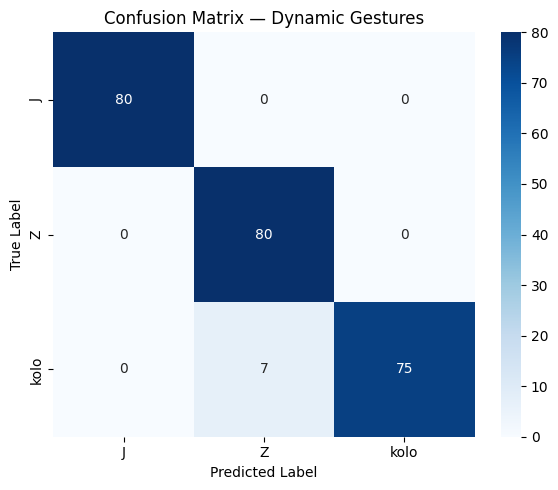

In [97]:
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

best_model = tf.keras.models.load_model('best_dynamic_model.keras')

y_pred_probs = best_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(max(6, len(CLASSES)), max(5, len(CLASSES))))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Dynamic Gestures')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_dynamic.png', dpi=150)
plt.show()

## Крок 7: Збереження моделі та метаданих

In [98]:
import json

best_model.save('dynamic_gesture_model.keras')

metadata = {
    'classes': CLASSES,
    'sequence_length': SEQUENCE_LENGTH,
    'feature_dim': 63,
    'model_type': best_model.name,
    'test_accuracy': float(acc)
}
with open('dynamic_model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model saved: dynamic_gesture_model.keras")
print("Metadata saved: dynamic_model_metadata.json")

Model saved: dynamic_gesture_model.keras
Metadata saved: dynamic_model_metadata.json


## Крок 8: Експеримент — порівняння архітектур

Запускаємо всі 3 моделі і порівнюємо результати.


Training: LSTM


c:\Users\user\.virtualenvs\ml_firman-h99lXOvd\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test accuracy : 96.69%
  Params         : 152,835
  Training time : 26.3s
  Best epoch    : 14

Training: GRU


c:\Users\user\.virtualenvs\ml_firman-h99lXOvd\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Test accuracy : 96.69%
  Params         : 116,483
  Training time : 38.9s
  Best epoch    : 30

Training: CNN+GRU
  Test accuracy : 97.11%
  Params         : 79,235
  Training time : 18.4s
  Best epoch    : 19

EXPERIMENT SUMMARY
  Model Test Accuracy Parameters Train Time (s)  Best Epoch
   LSTM        96.69%    152,835           26.3          14
    GRU        96.69%    116,483           38.9          30
CNN+GRU        97.11%     79,235           18.4          19


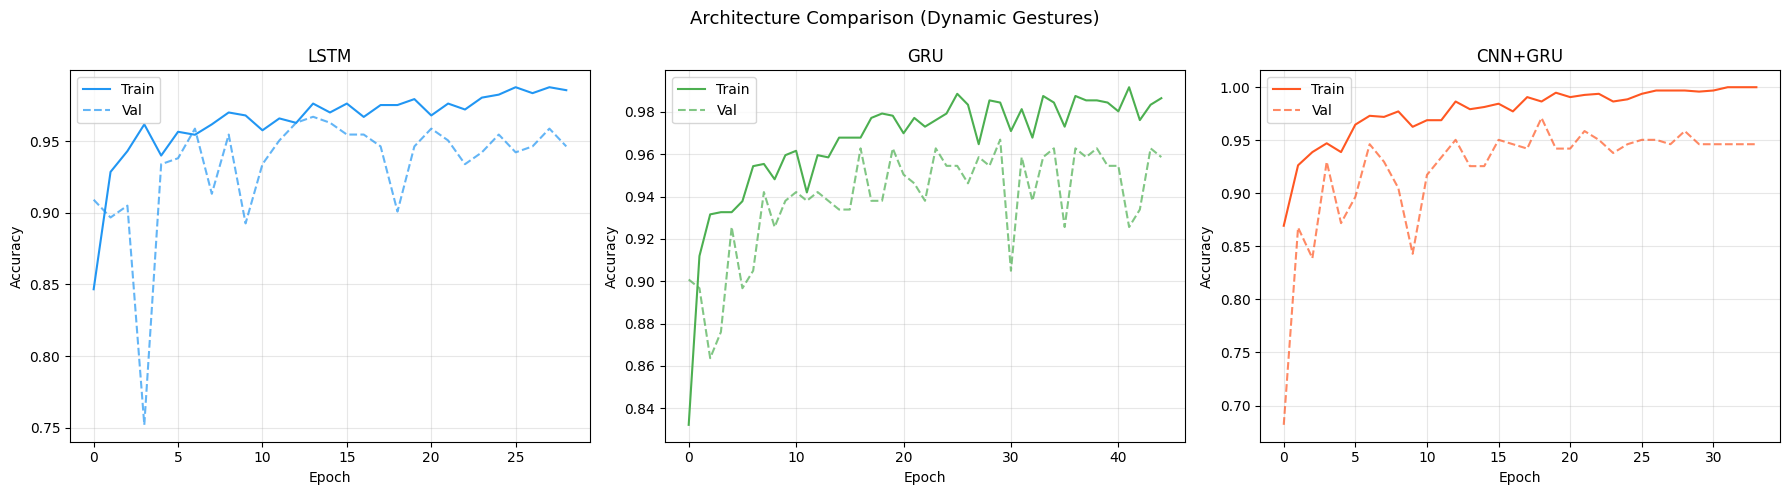

In [99]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def run_experiment(model_builder, name, X_tr, y_tr, X_te, y_te, epochs=100):
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")
    
    m = model_builder()
    m.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    cb = [
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8)
    ]
    
    start = time.time()
    hist = m.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=epochs,
        batch_size=32,
        callbacks=cb,
        verbose=0
    )
    elapsed = time.time() - start
    
    y_pred = np.argmax(m.predict(X_te, verbose=0), axis=1)
    test_acc = accuracy_score(np.argmax(y_te, axis=1), y_pred)
    num_params = m.count_params()
    best_epoch = np.argmax(hist.history['val_accuracy']) + 1
    
    print(f"  Test accuracy : {test_acc*100:.2f}%")
    print(f"  Params         : {num_params:,}")
    print(f"  Training time : {elapsed:.1f}s")
    print(f"  Best epoch    : {best_epoch}")
    
    return {
        'Model': name,
        'Test Accuracy': f"{test_acc*100:.2f}%",
        'Parameters': f"{num_params:,}",
        'Train Time (s)': f"{elapsed:.1f}",
        'Best Epoch': best_epoch
    }, m, hist

results = []
models_tested = {}

for builder, name in [
    (build_lstm_model,    'LSTM'),
    (build_gru_model,     'GRU'),
    (build_cnn_gru_model, 'CNN+GRU')
]:
    row, trained_model, trained_hist = run_experiment(
        builder, name,
        X_train, y_train_cat,
        X_test, y_test_cat
    )
    results.append(row)
    models_tested[name] = (trained_model, trained_hist)

print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
df_results.to_csv('experiment_results.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#2196F3', '#4CAF50', '#FF5722']
for i, (name, (_, h)) in enumerate(models_tested.items()):
    axes[i].plot(h.history['accuracy'], label='Train', color=colors[i])
    axes[i].plot(h.history['val_accuracy'], '--', label='Val', color=colors[i], alpha=0.7)
    axes[i].set_title(name)
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Architecture Comparison (Dynamic Gestures)', fontsize=13)
plt.tight_layout()
plt.savefig('architecture_comparison.png', dpi=150)
plt.show()

## Крок 9: Гібридна система реального часу

### Логіка вибору моделі:
```
Кадр з камери
      ↓
MediaPipe landmarks
      ↓
Додаємо до rolling buffer (останні 40 кадрів)
      ↓
  ┌───┴────────────────────────────┐
  │                                │
MLP (статичні)              LSTM/GRU (динамічні)
прогноз кожен кадр          прогноз кожні N кадрів
  │                                │
  └──────── Фінальне рішення ──────┘
  (якщо LSTM > threshold → динамічний жест)
```

In [100]:
import numpy as np
import tensorflow as tf
import json
import os

DYNAMIC_PATH = 'dynamic_gesture_model.keras'
META_PATH    = 'dynamic_model_metadata.json'

model = tf.keras.models.load_model(DYNAMIC_PATH)
with open(META_PATH) as f:
    meta = json.load(f)

print("="*50)
print(f"Model classes:      {meta['classes']}")
print(f"Sequence length:    {meta['sequence_length']}")
print(f"Model input shape:  {model.input_shape}")
print(f"SEQUENCE_LENGTH in code: {SEQUENCE_LENGTH}")
print("="*50)

if model.input_shape[1] != SEQUENCE_LENGTH:
    print(f"CRITICAL BUG: model expects {model.input_shape[1]} frames,")
    print(f"   but buffer collects {SEQUENCE_LENGTH}!")
else:
    print("Dimensions match")

dummy = np.random.rand(1, model.input_shape[1], 63).astype(np.float32)
out   = model.predict(dummy, verbose=0)[0]
print(f"\nTest (random input):")
for cls, prob in zip(meta['classes'], out):
    bar = '█' * int(prob * 30)
    print(f"  {cls:>8}: {prob:.4f}  {bar}")
print(f"\nMax confidence on random: {max(out):.4f}")
print("(if >0.8 on random - model is overfitted or untrained)")

Model classes:      ['J', 'Z', 'kolo']
Sequence length:    40
Model input shape:  (None, 40, 63)
SEQUENCE_LENGTH in code: 40
Dimensions match

Test (random input):
         J: 0.0270  
         Z: 0.4510  █████████████
      kolo: 0.5221  ███████████████

Max confidence on random: 0.5221
(if >0.8 on random - model is overfitted or untrained)


Loaded: (1207, 40, 63), classes: ['J', 'Z', 'kolo']

TEST 1: Are samples of the same class different?
(if std~0 - all samples are IDENTICAL - dataset is corrupted)
  J: inter-sample std=0.18156, intra-sample (motion) std=0.14162
  Z: inter-sample std=0.16386, intra-sample (motion) std=0.12176
  kolo: inter-sample std=0.16175, intra-sample (motion) std=0.11692

TEST 2: First frame of the first sample for each class
(if values are identical between classes, normalization might be excessive)
  J [0][0:9]: [ 0.      0.      0.     -0.1763 -0.0997 -0.0208 -0.2969 -0.3293 -0.0295]
  Z [0][0:9]: [ 0.      0.      0.     -0.1148 -0.1238 -0.0762 -0.1705 -0.3227 -0.1004]
  kolo [0][0:9]: [ 0.      0.      0.     -0.084  -0.1271 -0.056  -0.1153 -0.3085 -0.0689]

TEST 3: Average movement magnitude (displacement)
(should be > 0.01 for a dynamic gesture)
  J: mean motion per frame = 0.03511
  Z: mean motion per frame = 0.04080
  kolo: mean motion per frame = 0.03971

TEST 4: Similarity of mean traje

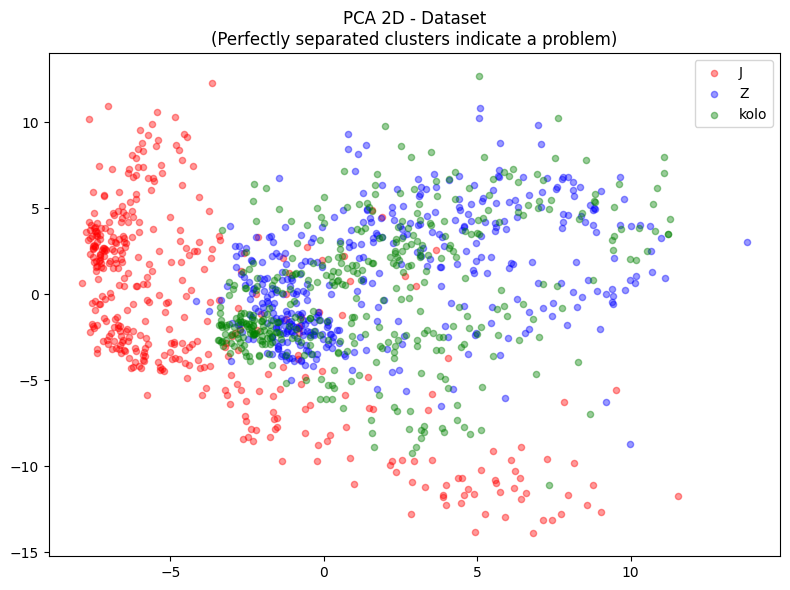

Saved: dataset_pca.png

TEST 6: Comparison of samples 0-4 of class J - first frame x,y coordinates
  J[0] frame0 points 0-1: [ 0.      0.      0.     -0.1763 -0.0997 -0.0208]
  J[1] frame0 points 0-1: [ 0.      0.      0.     -0.1367 -0.1251 -0.0392]
  J[2] frame0 points 0-1: [ 0.      0.      0.     -0.1456 -0.1159 -0.0359]
  J[3] frame0 points 0-1: [ 0.      0.      0.     -0.1473 -0.1135 -0.0441]
  J[4] frame0 points 0-1: [ 0.      0.      0.     -0.1264 -0.1504 -0.0407]

Diagnostics complete. Review the results above.
Key indicators: Test 1 (inter std) and Test 4 (cosine similarity)


In [101]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

DATA_DIR        = 'dataset_lstm/dynamic_dataset'
SEQUENCE_LENGTH = 40

def load_raw(data_dir):
    X, y, classes = [], [], []
    gesture_dirs = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d))
    ])
    for i, gesture in enumerate(gesture_dirs):
        gdir  = os.path.join(data_dir, gesture)
        files = sorted([f for f in os.listdir(gdir) if f.endswith('.npy')])
        for fname in files:
            seq = np.load(os.path.join(gdir, fname))
            if seq.shape == (SEQUENCE_LENGTH, 63):
                X.append(seq)
                y.append(i)
    return np.array(X, dtype=np.float32), np.array(y), gesture_dirs

X, y, classes = load_raw(DATA_DIR)
print(f"Loaded: {X.shape}, classes: {classes}")

print("\n" + "="*60)
print("TEST 1: Are samples of the same class different?")
print("(if std~0 - all samples are IDENTICAL - dataset is corrupted)")
print("="*60)
for i, cls in enumerate(classes):
    seqs = X[y == i]
    inter_std = seqs.std(axis=0).mean()
    intra_std = seqs.std(axis=1).mean()
    print(f"  {cls}: inter-sample std={inter_std:.5f}, intra-sample (motion) std={intra_std:.5f}")
    if inter_std < 0.001:
        print(f"    CRITICAL: all samples of {cls} are nearly IDENTICAL")
    if intra_std < 0.001:
        print(f"    CRITICAL: gesture {cls} has no movement (static)")

print("\n" + "="*60)
print("TEST 2: First frame of the first sample for each class")
print("(if values are identical between classes, normalization might be excessive)")
print("="*60)
for i, cls in enumerate(classes):
    first_sample_first_frame = X[y == i][0][0]
    print(f"  {cls} [0][0:9]: {first_sample_first_frame[:9].round(4)}")

print("\n" + "="*60)
print("TEST 3: Average movement magnitude (displacement)")
print("(should be > 0.01 for a dynamic gesture)")
print("="*60)
for i, cls in enumerate(classes):
    seqs = X[y == i]
    diffs = np.abs(np.diff(seqs, axis=1))
    mean_motion = diffs.mean()
    print(f"  {cls}: mean motion per frame = {mean_motion:.5f}")
    if mean_motion < 0.005:
        print(f"    WARNING: Low movement - gesture might be static or over-normalized")

print("\n" + "="*60)
print("TEST 4: Similarity of mean trajectories between classes")
print("(if > 0.99 - classes are indistinguishable)")
print("="*60)
means = {}
for i, cls in enumerate(classes):
    flat = X[y == i].mean(axis=0).flatten()
    means[cls] = flat / (np.linalg.norm(flat) + 1e-8)

for i, a in enumerate(classes):
    for b in classes[i+1:]:
        sim = np.dot(means[a], means[b])
        flag = " PROBLEM" if sim > 0.99 else (" similar" if sim > 0.95 else " OK")
        print(f"  {a} vs {b}: cosine={sim:.5f}  {flag}")

print("\n" + "="*60)
print("TEST 5: PCA - constructing 2D projection of the dataset")
print("If classes are PERFECTLY separated, the dataset is too simple (overfitting likely)")
print("="*60)

X_flat = X.reshape(len(X), -1)
pca    = PCA(n_components=2)
X_2d   = pca.fit_transform(X_flat)

plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']
for i, cls in enumerate(classes):
    mask = y == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                label=cls, alpha=0.4, s=20, c=colors[i % len(colors)])
plt.title('PCA 2D - Dataset\n(Perfectly separated clusters indicate a problem)')
plt.legend()
plt.tight_layout()
plt.savefig('dataset_pca.png', dpi=150)
plt.show()
print("Saved: dataset_pca.png")

print("\n" + "="*60)
print("TEST 6: Comparison of samples 0-4 of class J - first frame x,y coordinates")
print("="*60)
j_seqs = X[y == 0]
for k in range(min(5, len(j_seqs))):
    pt0 = j_seqs[k][0][:6]
    print(f"  J[{k}] frame0 points 0-1: {pt0.round(4)}")

print("\nDiagnostics complete. Review the results above.")
print("Key indicators: Test 1 (inter std) and Test 4 (cosine similarity)")

типу норм нижче


## Крок 10: Data Augmentation (якщо датасет малий)

Якщо маєш менше 200 семплів на жест — використовуй аугментацію.

In [102]:
def augment_sequence(seq, noise_std=0.005, time_warp_factor=0.1):
    aug = seq.copy()
    
    aug += np.random.normal(0, noise_std, aug.shape)
    
    T = aug.shape[0]
    warp = np.random.uniform(1 - time_warp_factor, 1 + time_warp_factor)
    new_t = np.linspace(0, T - 1, T)
    orig_t = np.clip(new_t / warp, 0, T - 1)
    aug = np.array([
        np.interp(orig_t, np.arange(T), aug[:, f])
        for f in range(aug.shape[1])
    ]).T
    
    scale = np.random.uniform(0.9, 1.1)
    aug *= scale
    
    return aug.astype(np.float32)


def augment_dataset(X, y, augment_factor=3):
    X_aug, y_aug = [X], [y]
    for _ in range(augment_factor - 1):
        X_new = np.array([augment_sequence(seq) for seq in X])
        X_aug.append(X_new)
        y_aug.append(y)
    return np.concatenate(X_aug), np.concatenate(y_aug)


print(f"Before augmentation: {X_train.shape}")
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, augment_factor=3)
print(f"After augmentation: {X_train_aug.shape}")

idx = np.random.permutation(len(X_train_aug))
X_train_aug = X_train_aug[idx]
y_train_aug = y_train_aug[idx]
y_train_aug_cat = to_categorical(y_train_aug, NUM_CLASSES)

print("\nTraining with augmented data...")
aug_model = build_gru_model()
aug_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
aug_model.fit(
    X_train_aug, y_train_aug_cat,
    validation_data=(X_test, y_test_cat),
    epochs=100, batch_size=32,
    callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=1
)
y_pred_aug = np.argmax(aug_model.predict(X_test), axis=1)
print(f"\nAccuracy with augmentation: {accuracy_score(y_test, y_pred_aug)*100:.2f}%")

Before augmentation: (965, 40, 63)
After augmentation: (2895, 40, 63)

Training with augmented data...
Epoch 1/100


c:\Users\user\.virtualenvs\ml_firman-h99lXOvd\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.8850 - loss: 0.2714 - val_accuracy: 0.9050 - val_loss: 0.4004
Epoch 2/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9406 - loss: 0.1415 - val_accuracy: 0.8967 - val_loss: 0.2620
Epoch 3/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.9613 - loss: 0.1045 - val_accuracy: 0.9463 - val_loss: 0.1123
Epoch 4/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.9734 - loss: 0.0734 - val_accuracy: 0.9587 - val_loss: 0.1110
Epoch 5/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9734 - loss: 0.0671 - val_accuracy: 0.9504 - val_loss: 0.1024
Epoch 6/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9713 - loss: 0.0717 - val_accuracy: 0.9421 - val_loss: 0.1261
Epoch 7/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9765 - loss: 0.0599 - val_accuracy: 0.8264 - val_loss: 0.6907
Epoch 8/100
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9713 - loss: 0.0717 - val_accuracy: 0.9545 - val_l

лише лстм


HYBRID


FINAL VERSION

In [103]:
"""
SignTalk — Hybrid Gesture Recognition
======================================
Combines:
  - MLP  → static gestures (all ASL letters except Z, J)
  - LSTM → dynamic gestures (Z, J, kolo)

Priority Logic:
  1. Every LSTM_EVAL_EVERY frame, check LSTM
  2. If LSTM confidence is >= threshold → announce dynamic gesture,
     clear buffer, block MLP for COOLDOWN_SECONDS
  3. If LSTM does not trigger and MLP is not blocked → MLP on the current frame
  4. MLP confirms the gesture through hold (~1.75s)
"""

import cv2
import time
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision
import tensorflow as tf
import joblib
import json
from collections import deque
import tkinter as tk
from tkinter import simpledialog

# ─── Paths — adjust to your folder structure ──────────────────────────────────
# MLP_MODEL_PATH     = '../model/sign_language_mlp.pkl'        # or 'updated_sign_model.pkl'
MLP_MODEL_PATH     = '../model/updated_sign_model.pkl'
DYNAMIC_MODEL_PATH = 'dynamic_gesture_model.keras'
META_PATH          = 'dynamic_model_metadata.json'
MP_MODEL_PATH      = 'hand_landmarker.task'
# ──────────────────────────────────────────────────────────────────────────────

# ─── Config ───────────────────────────────────────────────────────────────────
DYNAMIC_THRESHOLD  = 0.80   # LSTM confidence threshold
STATIC_THRESHOLD   = 0.60   # MLP confidence threshold
HOLD_DURATION      = 1.75   # Hold duration in seconds to confirm a static gesture
COOLDOWN_SECONDS   = 1.5    # Pause after a dynamic gesture (blocks both MLP and LSTM)
LSTM_EVAL_EVERY    = 5      # Run LSTM every N frames

# Motion threshold: average coordinate shift between adjacent frames in the buffer
# If the hand is stationary — LSTM is not called at all
# Adjust if needed: 0.005 = very sensitive, 0.02 = only explicit motion
MOTION_THRESHOLD   = 0.04

# Classes known by MLP but now processed by LSTM — block them in MLP
# If you've already retrained MLP without Z/J — leave the list empty: []
MLP_BLOCKED_LABELS = {'Z', 'J'}
# ──────────────────────────────────────────────────────────────────────────────

LABEL_MAP = {"2O": "2", "6O": "6", "SPACE": " "}

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(0,17),(17,18),(18,19),(19,20)
]


# ════════════════════════════════════════════════════════════════════════════════
#  Model loading
# ════════════════════════════════════════════════════════════════════════════════

print("Loading models...")

# MLP
if 'mlp_model' in dir() and 'known_classes' in dir():
    mlp, static_classes = mlp_model, known_classes
else:
    mlp, static_classes = joblib.load(MLP_MODEL_PATH)
mlp.warm_start  = False
n_features      = mlp.n_features_in_
all_mlp_classes = np.array(static_classes)


lstm_model = tf.keras.models.load_model(DYNAMIC_MODEL_PATH)
with open(META_PATH) as f:
    meta = json.load(f)
DYNAMIC_CLASSES = meta['classes']
SEQUENCE_LENGTH = meta['sequence_length']   

print(f" MLP:  {len(static_classes)} classes: {list(static_classes)}")
print(f" LSTM: {len(DYNAMIC_CLASSES)} classes: {DYNAMIC_CLASSES}")
print(f"   Sequence length: {SEQUENCE_LENGTH}")
print(f"   LSTM input shape: {lstm_model.input_shape}")
print(f"   MLP blocked classes (handled by LSTM): {MLP_BLOCKED_LABELS}")


# ════════════════════════════════════════════════════════════════════════════════
#  Normalization of landmarks — THE SAME for both models
# ════════════════════════════════════════════════════════════════════════════════

def extract_landmarks_normalized(hand_landmarks):
    bx, by, bz = hand_landmarks[0].x, hand_landmarks[0].y, hand_landmarks[0].z
    max_d = max(
        np.sqrt((lm.x - bx)**2 + (lm.y - by)**2)
        for lm in hand_landmarks
    )
    scale = max_d if max_d > 1e-6 else 1.0
    vec = []
    for lm in hand_landmarks:
        vec.extend([
            (lm.x - bx) / scale,
            (lm.y - by) / scale,
            (lm.z - bz) / scale,
        ])
    return vec  # 63 numbers


# ════════════════════════════════════════════════════════════════════════════════
#  Hybrid Recognizer
# ════════════════════════════════════════════════════════════════════════════════

class HybridRecognizer:
    """
    update(feat) → (label, confidence, source) or (None, 0.0, None)
    source: 'LSTM' | 'MLP' | None
    """

    def __init__(self):
        self.buffer       = deque(maxlen=SEQUENCE_LENGTH)
        self.frame_count  = 0
        self.last_trigger = 0.0   # Time of the last LSTM trigger
        self.last_probs   = None  # LSTM probs for debug HUD
        self.motion_level = 0.0   # Current motion level (for HUD)

    def _compute_motion(self):
        """
        Average displacement between adjacent frames in the buffer.
        Returns 0.0 if the buffer is not full.
        Stationary hand → ≈ 0.001, active motion → ≈ 0.02–0.10
        """
        if len(self.buffer) < 2:
            return 0.0
        arr   = np.array(self.buffer)           # (N, 63)
        diffs = np.abs(np.diff(arr, axis=0))    # (N-1, 63)
        return float(diffs.mean())

    def update(self, feat_vector):
        feat = np.array(feat_vector, dtype=np.float32)
        self.buffer.append(feat)
        self.frame_count += 1

        now         = time.time()
        in_cooldown = (now - self.last_trigger) < COOLDOWN_SECONDS

        # ── 1. LSTM — only during actual motion ─────────────────────────────
        if (len(self.buffer) == SEQUENCE_LENGTH
                and self.frame_count % LSTM_EVAL_EVERY == 0
                and not in_cooldown):

            self.motion_level = self._compute_motion()

            if self.motion_level >= MOTION_THRESHOLD:
                # Hand is moving — run LSTM
                seq   = np.array(self.buffer, dtype=np.float32)[np.newaxis]
                probs = lstm_model.predict(seq, verbose=0)[0]
                self.last_probs = probs

                conf = float(np.max(probs))
                idx  = int(np.argmax(probs))

                if conf >= DYNAMIC_THRESHOLD:
                    self.last_trigger = now
                    self.buffer.clear()
                    return DYNAMIC_CLASSES[idx], conf, 'LSTM'
            # else: hand is stationary — do not call LSTM, proceed to MLP

        # ── 2. MLP — every frame, if not in cooldown ────────────────────────
        if in_cooldown:
            return None, 0.0, None

        probs_mlp = mlp.predict_proba(feat.reshape(1, -1))[0]
        conf_mlp  = float(np.max(probs_mlp))
        label_mlp = static_classes[int(np.argmax(probs_mlp))]

        # Block classes that are now processed by LSTM
        if label_mlp in MLP_BLOCKED_LABELS:
            return None, 0.0, None

        if conf_mlp >= STATIC_THRESHOLD:
            return label_mlp, conf_mlp, 'MLP'

        return None, 0.0, None

    def get_buf_fill(self):
        return len(self.buffer)


# ════════════════════════════════════════════════════════════════════════════════
#  Transcript Manager
# ════════════════════════════════════════════════════════════════════════════════

class TranscriptManager:
    def __init__(self, hold_duration=HOLD_DURATION, max_display_chars=25):
        self.current_word    = ""
        self.sentence        = []
        self.last_letter     = None
        self.start_hold_time = 0.0
        self.hold_duration   = hold_duration
        self.is_confirmed    = False
        self.max_display_chars = max_display_chars

    def process_static(self, letter):
        """Hold-confirmation for MLP gestures."""
        now = time.time()
        if letter != self.last_letter:
            self.last_letter     = letter
            self.start_hold_time = now
            self.is_confirmed    = False
            return None
        if not self.is_confirmed and letter is not None:
            elapsed = now - self.start_hold_time
            if elapsed >= self.hold_duration:
                self._commit(letter)
                self.is_confirmed = True
                return 'READY'
            return elapsed
        return None

    def process_dynamic(self, label):
        """Immediate confirmation for LSTM gestures."""
        self._commit(label)

    def _commit(self, letter):
        if letter.upper() == 'SPACE':
            if self.sentence or self.current_word:
                self.sentence.append(self.current_word)
                self.current_word = ""
        else:
            self.current_word += letter

    def get_transcript(self):
        full = " ".join(self.sentence + ([self.current_word] if self.current_word else []))
        return ("..." + full[-self.max_display_chars:]) if len(full) > self.max_display_chars else full


# ════════════════════════════════════════════════════════════════════════════════
#  Main Loop
# ════════════════════════════════════════════════════════════════════════════════

root = tk.Tk()
root.withdraw()

recognizer  = HybridRecognizer()
transcript  = TranscriptManager()

base_options = mp_tasks.BaseOptions(model_asset_path=MP_MODEL_PATH)
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.6
)
detector = vision.HandLandmarker.create_from_options(options)
cap = cv2.VideoCapture(0)

show_skeleton  = True
show_debug     = True
current_feat   = [0.0] * n_features   # for correction

SOURCE_COLOR = {
    'MLP':  (0, 220, 0),       # green
    'LSTM': (255, 120, 0),     # orange
    None:   (128, 128, 128),
}

print("\n Started. Controls:")
print("   Q — quit | C — correction (MLP) | S — skeleton | D — debug panel | X — clear text")

try:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        frame = cv2.flip(frame, 1)
        h, w, _ = frame.shape

        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        results = detector.detect(mp_img)

        label, confidence, source = None, 0.0, None
        hand_detected = bool(results.hand_landmarks)

        if hand_detected:
            hand_lms = results.hand_landmarks[0]

            # Skeleton
            if show_skeleton:
                for (s, e) in HAND_CONNECTIONS:
                    cv2.line(frame,
                        (int(hand_lms[s].x*w), int(hand_lms[s].y*h)),
                        (int(hand_lms[e].x*w), int(hand_lms[e].y*h)),
                        (0, 255, 0), 2)
                for lm in hand_lms:
                    cv2.circle(frame, (int(lm.x*w), int(lm.y*h)), 4, (0,0,255), -1)

            current_feat = extract_landmarks_normalized(hand_lms)
            label, confidence, source = recognizer.update(current_feat)

            x_min = int(min(lm.x*w for lm in hand_lms))
            y_min = int(min(lm.y*h for lm in hand_lms))
            color = SOURCE_COLOR.get(source, (128,128,128))

            # Display prediction over the hand
            if label:
                display = LABEL_MAP.get(label, label)
                tag     = f"[{source}]"
                cv2.putText(frame, f"{display}  {int(confidence*100)}%  {tag}",
                    (x_min, max(45, y_min - 15)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

                if source == 'LSTM':
                    transcript.process_dynamic(display)

                elif source == 'MLP':
                    status = transcript.process_static(display)
                    if isinstance(status, float):
                        prog = int((status / HOLD_DURATION) * 150)
                        cv2.rectangle(frame,
                            (x_min, y_min-42), (x_min+150, y_min-30),
                            (40,40,40), -1)
                        cv2.rectangle(frame,
                            (x_min, y_min-42), (x_min+prog,  y_min-30),
                            (0,220,220), -1)

            # ── Debug panel: LSTM probabilities ────────────────────────────
            if show_debug and recognizer.last_probs is not None:
                panel_x = 10
                for i, (cls, prob) in enumerate(zip(DYNAMIC_CLASSES, recognizer.last_probs)):
                    bar_y   = 45 + i * 28
                    bar_w   = int(prob * 130)
                    is_best = (i == int(np.argmax(recognizer.last_probs)))
                    cv2.rectangle(frame, (panel_x, bar_y), (panel_x+130, bar_y+18), (30,30,30), -1)
                    clr = (0,200,0) if is_best else (80,80,180)
                    cv2.rectangle(frame, (panel_x, bar_y), (panel_x+bar_w, bar_y+18), clr, -1)
                    cv2.putText(frame, f"{cls}: {prob:.2f}",
                        (panel_x+135, bar_y+13),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.52, (210,210,210), 1)

        else:
            # Hand not visible — zeros in the buffer
            recognizer.buffer.append(np.zeros(63, dtype=np.float32))

        # ── Indicators (top right corner) ─────────────────────────────────
        buf      = recognizer.get_buf_fill()
        buf_frac = buf / SEQUENCE_LENGTH
        buf_full = (buf == SEQUENCE_LENGTH)

        # LSTM buffer
        cv2.rectangle(frame, (w-165, 10), (w-10, 27), (40,40,40), -1)
        cv2.rectangle(frame, (w-165, 10),
            (w-165 + int(buf_frac*155), 27),
            (255,140,0) if buf_full else (70,70,190), -1)
        cv2.putText(frame, f"LSTM buf {buf}/{SEQUENCE_LENGTH}",
            (w-165, 41), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (170,170,170), 1)

        # Cooldown
        now     = time.time()
        cd_left = COOLDOWN_SECONDS - (now - recognizer.last_trigger)
        if cd_left > 0:
            cd_frac = 1.0 - cd_left / COOLDOWN_SECONDS
            cv2.rectangle(frame, (w-165, 47), (w-10, 62), (40,40,40), -1)
            cv2.rectangle(frame, (w-165, 47),
                (w-165 + int(cd_frac*155), 62), (190,50,50), -1)
            cv2.putText(frame, f"cooldown {cd_left:.1f}s",
                (w-165, 76), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (170,170,170), 1)

        # Motion indicator — indicates whether LSTM runs
        motion      = recognizer.motion_level
        motion_frac = min(motion / (MOTION_THRESHOLD * 3), 1.0)  # saturates at 3x threshold
        motion_clr  = (0, 200, 0) if motion >= MOTION_THRESHOLD else (80, 80, 80)
        cv2.rectangle(frame, (w-165, 82), (w-10, 96), (40,40,40), -1)
        cv2.rectangle(frame, (w-165, 82),
            (w-165 + int(motion_frac*155), 96), motion_clr, -1)
        # Vertical line — threshold
        thresh_x = w - 165 + int((1.0/3.0) * 155)
        cv2.line(frame, (thresh_x, 80), (thresh_x, 98), (255,255,0), 1)
        label_clr = (0,220,0) if motion >= MOTION_THRESHOLD else (130,130,130)
        cv2.putText(frame, f"motion {motion:.4f}",
            (w-165, 110), cv2.FONT_HERSHEY_SIMPLEX, 0.4, label_clr, 1)

        # ── HUD at the bottom ────────────────────────────────────────────────
        cv2.rectangle(frame, (0, h-60), (w, h), (0,0,0), -1)
        sk_str = "ON" if show_skeleton else "OFF"
        cv2.putText(frame,
            f"SKEL:{sk_str} | {transcript.get_transcript()}",
            (15, h-18), cv2.FONT_HERSHEY_SIMPLEX, 0.85, (255,255,255), 2)
        cv2.putText(frame,
            "Q=quit  X=clear  C=correction  S=skeleton  D=debug",
            (10, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (170,170,170), 1)

        cv2.imshow('SignTalk — Hybrid', frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        elif key == ord('x'):
            transcript.current_word = ""
            transcript.sentence     = []
        elif key == ord('s'):
            show_skeleton = not show_skeleton
        elif key == ord('d'):
            show_debug = not show_debug
        elif key == ord('c') and hand_detected:
            # MLP correction — as in the original static program
            new_label = simpledialog.askstring("Correction", "Correct label:")
            if new_label:
                new_label = new_label.strip().upper()
                if new_label in all_mlp_classes:
                    for _ in range(2):
                        mlp.partial_fit([current_feat], [new_label], classes=all_mlp_classes)
                    print(f" MLP updated for: {new_label}")
                else:
                    print(f"  '{new_label}' not found in MLP classes")

finally:
    joblib.dump((mlp, static_classes), 'updated_sign_model.pkl')
    print(" MLP saved: updated_sign_model.pkl")
    cap.release()
    cv2.destroyAllWindows()
    root.destroy()

Loading models...
 MLP:  39 classes: ['1', '10', '2', '2O', '3', '4', '5', '6', '6O', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'SPACE', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
 LSTM: 3 classes: ['J', 'Z', 'kolo']
   Sequence length: 40
   LSTM input shape: (None, 40, 63)
   MLP blocked classes (handled by LSTM): {'J', 'Z'}

 Started. Controls:
   Q — quit | C — correction (MLP) | S — skeleton | D — debug panel | X — clear text
 MLP saved: updated_sign_model.pkl
